In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
from sksurv.datasets import load_gbsg2
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
 
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from lifelines import CoxPHFitter
from sklearn.preprocessing import RobustScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,event_OS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,114.312329,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,111.846575,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,49.479452,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,66.739726,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,42.805479,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,42.739726,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,42.312329,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,42.246575,0


In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D1
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [7]:
# need to choose patient_id from OUS_D1 and OUS_OS_target in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [8]:
# Merge MAASTRO_D1 with response_ous
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [9]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [10]:
# Check if some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event


In [11]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [12]:
# Change the form of MAASTRO 
# X
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]

# y_MAASTRO into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

# Check the shape of clincial_test
clinical_test.shape

(99, 16)

In [13]:
clinical_train.head(10)

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,event_OS
0,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,114.312329,0
1,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,111.846575,0
2,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,49.479452,1
3,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,66.739726,1
5,57.772603,1,0,0,0,1,1,0.0,0,59.658904,1.0,5.298506,2.846,10.424669,21.106849,1
6,55.791781,0,0,0,0,1,1,0.0,0,56.687671,1.0,8.340148,4.786,31.461777,87.978082,1
7,72.389041,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.301212,7.852,55.919707,62.005479,1
8,53.378082,1,0,1,0,0,1,1.0,0,0.000000,0.0,19.134939,5.898,92.534072,105.073973,0
9,59.076712,0,0,0,1,0,0,0.0,1,41.076712,1.0,17.184191,25.172,317.330329,20.613699,1


# Feature Selection

In [14]:
# Define the columns to be excluded from standardization
excluded_columns = ['female', 
                    'cavum_oris',
                    'oropharynx',
                    'hypopharynx',
                    'larynx',
                    'histgrade_high',
                    'hpv_related',
                    'charlson',
                    'uicc8_III-IV'
                   ]

y_event_os = y['event_OS']

final_sum_results = []  # Store sum results across all iterations

for random_state in range(10): 
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    sum_results = []  # Store sum results for each fold
    
    for train_index, test_index in skf.split(X, y_event_os):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Standardize the included columns
        scaler = RobustScaler()
        X_train_std = scaler.fit_transform(X_train)
        X_test_std = scaler.transform(X_test)

        # Change it to a dataframe
        X_train_std = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)
        X_test_std = pd.DataFrame(X_test_std, columns=X_test.columns, index=X_test.index)
        
        final_train_df = pd.concat([X_train_std, y_train], axis=1)
        final_test_df = pd.concat([X_test_std, y_test], axis=1)

        # Fit Cox proportional hazards regression model
        coxph = CoxPHFitter(penalizer=0.0001)
        coxph.fit(final_train_df, duration_col='OS', event_col='event_OS')

        # Get coefficients and associated feature names
        coefficients = coxph.summary['coef']
        feature_names = coxph.summary.index

        # Create a DataFrame to store coefficients and feature names
        coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

        # Take absolute values of coefficients
        coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

        # Sort coefficients by absolute value to identify important features
        sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)
        
        # Sum absolute coefficients for each feature
        sum_abs_coefficient = sorted_coefficients_df.groupby('Feature')['Abs_Coefficient'].sum().reset_index()
        
        # Append to sum_results for this fold
        sum_results.append(sum_abs_coefficient)

    # Concatenate sum_results for all folds
    fold_sum_results = pd.concat(sum_results)
    
    # Group by 'Feature' and calculate the sum of 'Abs_Coefficient' across all folds
    final_sum_fold = fold_sum_results.groupby('Feature')['Abs_Coefficient'].sum().reset_index()
    
    # Append to final_sum_results for all random states
    final_sum_results.append(final_sum_fold)

# Concatenate the DataFrames for all random states
final_result = pd.concat(final_sum_results)

# Group by 'Feature' and calculate the sum of 'Abs_Coefficient' across all iterations and folds
final_sum = final_result.groupby('Feature')['Abs_Coefficient'].sum().reset_index()

# Rename the column for clarity
final_sum.columns = ['Feature', 'Final_Sum_Abs_Coefficient']

final_sum_sorted = final_sum.sort_values(by='Final_Sum_Abs_Coefficient', ascending=False)

# Display the final result
print(final_sum_sorted)

<lifelines.CoxPHFitter: fitted with 111 total observations, 65 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 65 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 66 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 66 right-censored observations>

<lifelines.CoxPHFitter: fitted with 112 total observations, 66 right-censored observations>

...

<lifelines.CoxPHFitter: fitted with 111 total observations, 65 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 66 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 66 right-censored observations>

<lifelines.CoxPHFitter: fitted with 112 total observations, 66 right-censored observations>

           Feature  Final_Sum_Abs_Coefficient
8      hpv_related                  77.430708
13    uicc8_III-IV                  36.968251
9      hypopharynx                  30.384528
0              MTV                  26.244650
5         charlson                  25.895731
11      oropharynx                  19.861037
2              TLG                  18.661410
10          larynx                  17.511419
3              age                  16.241845
4       cavum_oris                  14.978429
6           female                  13.984494
12      pack_years                  13.486723
1          SUVpeak                  11.791009
7   histgrade_high                   9.139413


<Figure size 1000x600 with 0 Axes>

<BarContainer object of 14 artists>

Text(0.5, 0, 'Features')

Text(0, 0.5, 'Sum of Absolute Importance Values')

Text(0.5, 1.0, 'Feature Importance using CoxPH Fitter')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

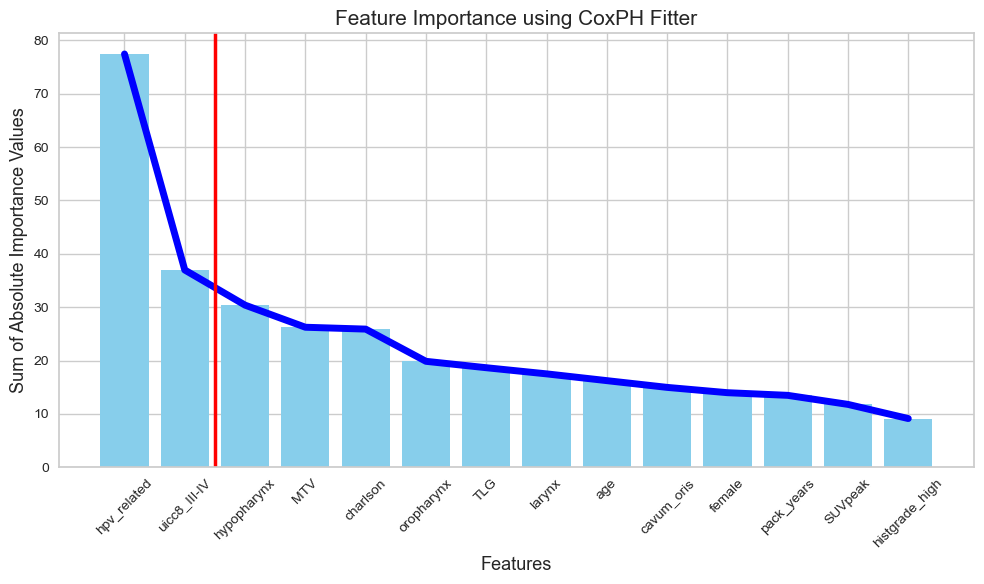

In [21]:
# Plot the bar graph
plt.figure(figsize=(10, 6)) 
plt.bar(final_sum_sorted['Feature'], 
        final_sum_sorted['Final_Sum_Abs_Coefficient'], 
        color='skyblue')
plt.plot(final_sum_sorted['Feature'], 
         final_sum_sorted['Final_Sum_Abs_Coefficient'], 
         color='blue',
        linewidth=5)
plt.xlabel('Features', fontsize=13) 
plt.ylabel('Sum of Absolute Importance Values', fontsize=13) 
plt.title('Feature Importance using CoxPH Fitter', fontsize=15)
plt.xticks(rotation=45) 
plt.axvline(x=1.5, color='red', linestyle='-', linewidth=2.5) 
plt.tight_layout()  
plt.show()

In [22]:
selected_features = final_sum_sorted[0:2]['Feature']
selected_features

8      hpv_related
13    uicc8_III-IV
Name: Feature, dtype: object

In [23]:
# Selecting features in the DataFrame
X_cfi = X[selected_features]
X_new = X_cfi.copy()

X_MAASTRO_cfi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_cfi.copy()

# Standardization

In [24]:
""" 
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = RobustScaler()
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]
"""
X_new_std = X_new.copy()

" \n# Standardize X_new, the new data with the selected features only \ncategorical_columns = ['female', \n                        'cavum_oris',\n                        'oropharynx',\n                        'hypopharynx',\n                        'larynx',\n                        'histgrade_high',\n                        'hpv_related',\n                        'charlson',\n                        'uicc8_III-IV']\n\n# Set the columns_to_drop which are categorical \ncolumns_to_drop = [col for col in X_new.columns if col in categorical_columns]\n\n# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric\nX_new_categoric = X_new[columns_to_drop]\nX_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)\n\n# Do the standardization for the numeric part \nscaler = RobustScaler()\nX_new_numeric_columns = X_new_numeric.columns\nX_new_numeric_index = X_new_numeric.index \nX_new_numeric_std = scaler.fit_transform(X_new_numeric)\nX_new_numeric_std 

In [25]:
"""
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = RobustScaler()
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]
""" 
MAASTRO_new_std = MAASTRO_new.copy()

'\n# Standardize X_MAASTRO \n# Set the columns_to_drop which are categorical \ncolumns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]\n\n# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric\nMAASTRO_new_categoric = MAASTRO_new[columns_to_drop]\nMAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)\n\n# Do the standardization for the numeric part \nscaler = RobustScaler()\nMAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns\nMAASTRO_new_numeric_index = MAASTRO_new_numeric.index \nMAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)\nMAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,\n                                 columns=MAASTRO_new_numeric_columns, \n                                 index=MAASTRO_new_numeric_index)\nMAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)\n\n# Change the order of the X_new_std \nMAASTRO_new_std = M

In [26]:
X_new

,hpv_related,uicc8_III-IV
0,0.0,0.0
1,0.0,0.0
2,0.0,1.0
3,0.0,0.0
4,0.0,0.0
...,...,...
134,1.0,0.0
135,1.0,1.0
136,1.0,0.0
137,1.0,1.0


In [27]:
X_new_std

,hpv_related,uicc8_III-IV
0,0.0,0.0
1,0.0,0.0
2,0.0,1.0
3,0.0,0.0
4,0.0,0.0
...,...,...
134,1.0,0.0
135,1.0,1.0
136,1.0,0.0
137,1.0,1.0


In [28]:
MAASTRO_new

,hpv_related,uicc8_III-IV
0,1,0
1,0,1
2,0,1
3,0,1
4,1,0
...,...,...
94,0,1
95,0,1
96,1,1
97,1,0


In [29]:
MAASTRO_new_std

,hpv_related,uicc8_III-IV
0,1,0
1,0,1
2,0,1
3,0,1
4,1,0
...,...,...
94,0,1
95,0,1
96,1,1
97,1,0


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [30]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler()
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:35:35,961] A new study created in memory with name: no-name-9a25165c-a2bf-4651-b040-1d46f9b761b0


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824


[I 2024-04-13 23:35:36,492] A new study created in memory with name: no-name-f64a644c-0ba8-4031-9d14-9caec43e4050


Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:35:36,487] Trial 0 finished with value: 0.7269000780104259 and parameters: {}. Best is trial 0 with value: 0.7269000780104259.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7269000780104259], datetime_start=datetime.datetime(2024, 4, 13, 23, 35, 36, 60855), datetime_complete=datetime.datetime(2024, 4, 13, 23, 35, 36, 482874), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7269000780104259


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.15713666272808063
Fold 2 IBS: 0.21662044753267654
Fold 3 IBS: 0.17155903987730828
Fold 4 IBS: 0.15364262323455724
Fold 5 IBS: 0.23950724114353725
[I 2024-04-13 23:35:37,078] Trial 0 finished with value: 0.187693202903232 and parameters: {}. Best is trial 0 with value: 0.187693202903232.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.187693202903232], datetime_start=datetime.datetime(2024, 4, 13, 23, 35, 36, 542376), datetime_complete=datetime.datetime(2024, 4, 13, 23, 35, 37, 78089), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.187693202903232


In [31]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [32]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.727
train_ibs:  0.188


#### Test

In [33]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [34]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.593
IBS score: 0.222


In [35]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [36]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [37]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler()
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:35:37,373] A new study created in memory with name: no-name-5cd76ba6-b889-4575-9518-a0916eac3d4a


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7424242424242424


[I 2024-04-13 23:35:37,592] A new study created in memory with name: no-name-d6d9af42-5a88-4b8c-aeb5-349f6d49a26f


Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7745098039215687
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6150234741784038
[I 2024-04-13 23:35:37,576] Trial 0 finished with value: 0.7268586529897133 and parameters: {}. Best is trial 0 with value: 0.7268586529897133.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7268586529897133], datetime_start=datetime.datetime(2024, 4, 13, 23, 35, 37, 409743), datetime_complete=datetime.datetime(2024, 4, 13, 23, 35, 37, 576608), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7268586529897133


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397651777490725
Fold 2 IBS: 0.2215779141699564
Fold 3 IBS: 0.20453594224963634
Fold 4 IBS: 0.224738034459558
Fold 5 IBS: 0.2181243143679756
[I 2024-04-13 23:35:37,847] Trial 0 finished with value: 0.2165905446044067 and parameters: {}. Best is trial 0 with value: 0.2165905446044067.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2165905446044067], datetime_start=datetime.datetime(2024, 4, 13, 23, 35, 37, 624617), datetime_complete=datetime.datetime(2024, 4, 13, 23, 35, 37, 847407), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2165905446044067


In [38]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [39]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.727
train_ibs:  0.217


#### Test

In [40]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [41]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.593


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [42]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [43]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler()
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:35:38,152] A new study created in memory with name: no-name-f558b7e5-e8cd-42f0-ac99-989188832371


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806


[I 2024-04-13 23:35:38,610] A new study created in memory with name: no-name-280fd137-38f6-4290-8fd3-239427780cac


Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:35:38,603] Trial 0 finished with value: 0.7269000780104259 and parameters: {}. Best is trial 0 with value: 0.7269000780104259.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7269000780104259], datetime_start=datetime.datetime(2024, 4, 13, 23, 35, 38, 257097), datetime_complete=datetime.datetime(2024, 4, 13, 23, 35, 38, 603262), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7269000780104259


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.15803303563405158
Fold 2 IBS: 0.2158970623421663
Fold 3 IBS: 0.17131926344963797
Fold 4 IBS: 0.15427451652948604
Fold 5 IBS: 0.2383491786253993
[I 2024-04-13 23:35:39,219] Trial 0 finished with value: 0.18757461131614822 and parameters: {}. Best is trial 0 with value: 0.18757461131614822.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.18757461131614822], datetime_start=datetime.datetime(2024, 4, 13, 23, 35, 38, 651887), datetime_complete=datetime.datetime(2024, 4, 13, 23, 35, 39, 219096), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.18757461131614822


In [44]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [45]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.727
train_ibs:  0.188


#### Test

In [46]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [47]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.593


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.221


In [48]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [49]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler()
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:35:39,605] A new study created in memory with name: no-name-bd4c5896-19ed-4621-9eb4-52ced2591003


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:35:40,208] Trial 0 finished with value: 0.7269000780104259 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.7269000780104259.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:35:40,673] Trial 1 finished with value: 0.7269000780104259 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.7269000780104259.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:35:41,172] Trial 2 finished with value: 0.7269000780104259 and parameters: {'l1_ratio': 0.22692876841884668}.

Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:35:51,373] Trial 24 finished with value: 0.7269000780104259 and parameters: {'l1_ratio': 0.15433706302991543}. Best is trial 0 with value: 0.7269000780104259.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:35:52,073] Trial 25 finished with value: 0.7269000780104259 and parameters: {'l1_ratio': 0.4626599986704694}. Best is trial 0 with value: 0.7269000780104259.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:35:52,635] Trial 26 finished with value: 0.7269000780104259 and parameters: {'l1_ratio': 0.3312072877416866

Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:36:03,522] Trial 48 finished with value: 0.7269000780104259 and parameters: {'l1_ratio': 0.5675456270820948}. Best is trial 0 with value: 0.7269000780104259.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:36:04,038] Trial 49 finished with value: 0.7269000780104259 and parameters: {'l1_ratio': 0.7153190338760974}. Best is trial 0 with value: 0.7269000780104259.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:36:04,608] Trial 50 finished with value: 0.7269000780104259 and parameters: {'l1_ratio': 0.5027665121167861}

...

Fold 1 IBS: 0.15762994312495557
Fold 2 IBS: 0.21562254726858204
Fold 3 IBS: 0.17132108282641184
Fold 4 IBS: 0.15425961878453484
Fold 5 IBS: 0.23838923108080606
[I 2024-04-13 23:36:29,235] Trial 0 finished with value: 0.18744448461705807 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.18744448461705807.
Fold 1 IBS: 0.1571187092898912
Fold 2 IBS: 0.21531709884591302
Fold 3 IBS: 0.17133748437798
Fold 4 IBS: 0.15419505247222726
Fold 5 IBS: 0.23846512070139134
[I 2024-04-13 23:36:29,701] Trial 1 finished with value: 0.18728669313748056 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.18728669313748056.
Fold 1 IBS: 0.1570513663954925
Fold 2 IBS: 0.21519681584872366
Fold 3 IBS: 0.17135021373191367
Fold 4 IBS: 0.1541555114640914
Fold 5 IBS: 0.2384224411243741
[I 2024-04-13 23:36:30,305] Trial 2 finished with value: 0.18723526971291907 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.1872352697129190

Fold 1 IBS: 0.1568782032423509
Fold 2 IBS: 0.21506560921627216
Fold 3 IBS: 0.17135993672763414
Fold 4 IBS: 0.15416895988021861
Fold 5 IBS: 0.23852614670892947
[I 2024-04-13 23:36:42,209] Trial 25 finished with value: 0.18719977115508107 and parameters: {'l1_ratio': 0.06766854141508033}. Best is trial 18 with value: 0.1871844766714557.
Fold 1 IBS: 0.15699892119824324
Fold 2 IBS: 0.215244505544044
Fold 3 IBS: 0.17134598705512438
Fold 4 IBS: 0.15416562624853014
Fold 5 IBS: 0.23848181406884597
[I 2024-04-13 23:36:42,744] Trial 26 finished with value: 0.18724737082295756 and parameters: {'l1_ratio': 0.18135027164438178}. Best is trial 18 with value: 0.1871844766714557.
Fold 1 IBS: 0.15748316457915595
Fold 2 IBS: 0.21553286248156323
Fold 3 IBS: 0.1713305352132454
Fold 4 IBS: 0.15422739518610118
Fold 5 IBS: 0.23840910111294572
[I 2024-04-13 23:36:43,179] Trial 27 finished with value: 0.18739661171460228 and parameters: {'l1_ratio': 0.58416616744615}. Best is trial 18 with value: 0.18718447667

Fold 1 IBS: 0.15691505172617182
Fold 2 IBS: 0.21506042172377327
Fold 3 IBS: 0.17135316757142932
Fold 4 IBS: 0.15414147911629203
Fold 5 IBS: 0.2384997071891464
[I 2024-04-13 23:36:55,382] Trial 50 finished with value: 0.18719396546536257 and parameters: {'l1_ratio': 0.10509820281177144}. Best is trial 18 with value: 0.1871844766714557.
Fold 1 IBS: 0.15691535687815292
Fold 2 IBS: 0.21506224442850547
Fold 3 IBS: 0.17135337623082605
Fold 4 IBS: 0.15414089119338267
Fold 5 IBS: 0.2385008571917873
[I 2024-04-13 23:36:56,031] Trial 51 finished with value: 0.18719454518453088 and parameters: {'l1_ratio': 0.10522363173012594}. Best is trial 18 with value: 0.1871844766714557.
Fold 1 IBS: 0.15691379472521072
Fold 2 IBS: 0.21519469525822765
Fold 3 IBS: 0.17135230704351437
Fold 4 IBS: 0.15414390658595414
Fold 5 IBS: 0.23849496094068176
[I 2024-04-13 23:36:56,626] Trial 52 finished with value: 0.18721993291071773 and parameters: {'l1_ratio': 0.10458357467394563}. Best is trial 18 with value: 0.187184

Fold 5 IBS: 0.238433756837461
[I 2024-04-13 23:37:08,676] Trial 74 finished with value: 0.18720985718212937 and parameters: {'l1_ratio': 0.15730130567809597}. Best is trial 18 with value: 0.1871844766714557.
Fold 1 IBS: 0.15693111330248347
Fold 2 IBS: 0.21517603364274174
Fold 3 IBS: 0.17134657824403446
Fold 4 IBS: 0.15416119387302438
Fold 5 IBS: 0.23846918776931691
[I 2024-04-13 23:37:09,173] Trial 75 finished with value: 0.18721682136632017 and parameters: {'l1_ratio': 0.12289665561445065}. Best is trial 18 with value: 0.1871844766714557.
Fold 1 IBS: 0.15723294844792057
Fold 2 IBS: 0.21530180271301103
Fold 3 IBS: 0.17133535479149492
Fold 4 IBS: 0.15420555042553788
Fold 5 IBS: 0.23848021853270399
[I 2024-04-13 23:37:09,653] Trial 76 finished with value: 0.18731117498213365 and parameters: {'l1_ratio': 0.3870355975595541}. Best is trial 18 with value: 0.1871844766714557.
Fold 1 IBS: 0.21293922295476392
Fold 2 IBS: 0.22083253576721232
Fold 3 IBS: 0.20327900845574093
Fold 4 IBS: 0.2230141

Fold 1 IBS: 0.2134782138629655
Fold 2 IBS: 0.22121886441628427
Fold 3 IBS: 0.2039315375202502
Fold 4 IBS: 0.22391011255999455
Fold 5 IBS: 0.21801991432190707
[I 2024-04-13 23:37:21,640] Trial 99 finished with value: 0.2161117285362803 and parameters: {'l1_ratio': 0.012053737855797338}. Best is trial 81 with value: 0.18718042703484328.


* Best trial for IBS: 
 FrozenTrial(number=81, state=TrialState.COMPLETE, values=[0.18718042703484328], datetime_start=datetime.datetime(2024, 4, 13, 23, 37, 11, 257871), datetime_complete=datetime.datetime(2024, 4, 13, 23, 37, 11, 771483), params={'l1_ratio': 0.06631551811424707}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=81, value=None)


* Best Score for IBS: 
 0.18718042703484328


In [50]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [51]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.727
train_ibs:  0.187


#### Test

In [52]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [53]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.6964995386793018)

test_cindex : 0.593


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.06631551811424707)

test_ibs:  0.221


In [54]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [55]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:37:22,047] A new study created in memory with name: no-name-50c3e2e1-68cb-46bd-93de-84a4895eae21


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6197183098591549
[I 2024-04-13 23:37:26,755] Trial 0 finished with value: 0.7287780122827263 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.7287780122827263.
Fold 1 C-index: 0.7467532467532467
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7696078431372549
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6197183098591549
[I 2024-04-13 23:37:30,964] Trial 1 finished with value: 0.7276830288348017 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 

Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:38:31,169] Trial 15 finished with value: 0.7349357922961401 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 7, 'min_samples_leaf': 10, 'max_depth': 17, 'n_estimators': 163, 'oob_score': True, 'max_samples': 0.4747428535255964, 'max_features': None, 'min_weight_fraction_leaf': 0.20648604556011108, 'warm_start': False}. Best is trial 15 with value: 0.7349357922961401.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 23:38:33,141] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 7, 'min_samples_leaf': 16, 'max_depth': 20, 'n_estimators': 95, 'oob_score': True, 'max_samples': 0.33594576018228706, 'max_features': None, 'min_weight_fraction_leaf': 0.21564544203258088, 'warm_start': False}. Best is trial 15 with value: 0.7349357922961401.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold

Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:39:41,679] Trial 31 finished with value: 0.7349357922961401 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 3, 'min_samples_leaf': 6, 'max_depth': 8, 'n_estimators': 500, 'oob_score': True, 'max_samples': 0.3163077714244212, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.1296242424201944, 'warm_start': True}. Best is trial 15 with value: 0.7349357922961401.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-13 23:39:45,426] Trial 32 finished with value: 0.7349357922961401 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 5, 'min_samples_leaf': 5, 'max_depth': 6, 'n_estimators': 457, 'oob_score': True, 'max_samples': 0.3744899663128042, 

...

Fold 1 IBS: 0.15771732459585694
Fold 2 IBS: 0.204997886566939
Fold 3 IBS: 0.17110365213107648
Fold 4 IBS: 0.15986765876068523
Fold 5 IBS: 0.23399888817739722
[I 2024-04-13 23:51:00,746] Trial 32 finished with value: 0.18553708204639097 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 9, 'min_samples_leaf': 19, 'max_depth': 16, 'n_estimators': 459, 'oob_score': True, 'max_samples': 0.8004006083549043, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.19558060234973634}. Best is trial 9 with value: 0.18533021379567297.
Fold 1 IBS: 0.15885462604016393
Fold 2 IBS: 0.20326241240357476
Fold 3 IBS: 0.17082002424721068
Fold 4 IBS: 0.162521940922153
Fold 5 IBS: 0.22862698439124804
[I 2024-04-13 23:51:25,116] Trial 33 finished with value: 0.18481719760087006 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 5, 'min_samples_leaf': 17, 'max_depth': 19, 'n_estimators': 496, 'oob_score': True, 'max_samples': 0.6856570221046583, 'max_features': 'sqrt', 'min_weight_fraction_leaf

Fold 5 IBS: 0.22055295272351208
[I 2024-04-13 23:56:08,777] Trial 47 finished with value: 0.18606541635051205 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 17, 'min_samples_leaf': 20, 'max_depth': 19, 'n_estimators': 293, 'oob_score': False, 'max_samples': 0.8020362069886561, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.320201630468352}. Best is trial 42 with value: 0.18386877878834285.
Fold 1 IBS: 0.21398813444206818
Fold 2 IBS: 0.2213330362263486
Fold 3 IBS: 0.204796300838126
Fold 4 IBS: 0.2246686617528624
Fold 5 IBS: 0.21864778332407528
[I 2024-04-13 23:56:29,829] Trial 48 finished with value: 0.21668678331669605 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 4, 'min_samples_leaf': 13, 'max_depth': 20, 'n_estimators': 415, 'oob_score': False, 'max_samples': 0.6980806119184451, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.44962767788541247}. Best is trial 42 with value: 0.18386877878834285.
Fold 1 IBS: 0.15715847663902754
Fold 2 IBS: 0.2063

Fold 1 IBS: 0.1578084023793108
Fold 2 IBS: 0.20419489240052166
Fold 3 IBS: 0.17119112651747684
Fold 4 IBS: 0.16284245616754797
Fold 5 IBS: 0.2262518635334634
[I 2024-04-14 00:02:00,967] Trial 63 finished with value: 0.18445774819966415 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 15, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 429, 'oob_score': False, 'max_samples': 0.927876356124675, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.33547597111728134}. Best is trial 42 with value: 0.18386877878834285.
Fold 1 IBS: 0.15766104941247241
Fold 2 IBS: 0.20512759151061102
Fold 3 IBS: 0.17122368724090833
Fold 4 IBS: 0.16299973623991865
Fold 5 IBS: 0.22695952999463312
[I 2024-04-14 00:02:19,585] Trial 64 finished with value: 0.1847943188797087 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 16, 'min_samples_leaf': 9, 'max_depth': 13, 'n_estimators': 368, 'oob_score': False, 'max_samples': 0.9647337823000391, 'max_features': 'auto', 'min_weight_fraction_

Fold 4 IBS: 0.17738266427577754
Fold 5 IBS: 0.2154568997880138
[I 2024-04-14 00:06:24,165] Trial 78 finished with value: 0.18606508729627297 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 14, 'min_samples_leaf': 14, 'max_depth': 14, 'n_estimators': 376, 'oob_score': False, 'max_samples': 0.8535082206738337, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.35729601601272376}. Best is trial 42 with value: 0.18386877878834285.
Fold 1 IBS: 0.21397257775180992
Fold 2 IBS: 0.22139133453374035
Fold 3 IBS: 0.20496040414009542
Fold 4 IBS: 0.22466277216300115
Fold 5 IBS: 0.21822356565168266
[I 2024-04-14 00:06:44,396] Trial 79 finished with value: 0.21664213084806588 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 17, 'min_samples_leaf': 12, 'max_depth': 15, 'n_estimators': 483, 'oob_score': False, 'max_samples': 0.32742494844981485, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.3744347672133185}. Best is trial 42 with value: 0.18386877878834285.
Fold 1 IBS: 0

Fold 1 IBS: 0.1581482798010809
Fold 2 IBS: 0.20588738521263478
Fold 3 IBS: 0.1713843948920589
Fold 4 IBS: 0.16210991499888877
Fold 5 IBS: 0.22482347138450082
[I 2024-04-14 00:10:23,231] Trial 94 finished with value: 0.1844706892578328 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 13, 'min_samples_leaf': 12, 'max_depth': 8, 'n_estimators': 307, 'oob_score': False, 'max_samples': 0.8678119829755734, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.315299422512942}. Best is trial 42 with value: 0.18386877878834285.
Fold 1 IBS: 0.1851242269281942
Fold 2 IBS: 0.20504831826545297
Fold 3 IBS: 0.1848073654711225
Fold 4 IBS: 0.2033116844022442
Fold 5 IBS: 0.21487811925485029
[I 2024-04-14 00:10:38,965] Trial 95 finished with value: 0.19863394286437286 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 12, 'min_samples_leaf': 13, 'max_depth': 9, 'n_estimators': 391, 'oob_score': False, 'max_samples': 0.7437476881829567, 'max_features': 'log2', 'min_weight_fraction_leaf

In [56]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [57]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.735
train_ibs:  0.184


#### Test

In [58]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [59]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=17, max_features=None, max_leaf_nodes=7,
                     max_samples=0.4747428535255964, min_samples_leaf=10,
                     min_samples_split=17,
                     min_weight_fraction_leaf=0.20648604556011108,
                     n_estimators=163, oob_score=True, random_state=123)

test_cindex:  0.593


RandomSurvivalForest(max_depth=20, max_features='auto', max_leaf_nodes=6,
                     max_samples=0.7693291409531149, min_samples_leaf=17,
                     min_samples_split=3,
                     min_weight_fraction_leaf=0.2864683505363934,
                     n_estimators=483, random_state=123)

test_ibs:  0.209


In [60]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [61]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 00:31:04,527] A new study created in memory with name: no-name-a87387bb-967b-4891-a730-ee42493aafe6


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7467532467532467
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7696078431372549
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6197183098591549
[I 2024-04-14 00:31:08,526] Trial 0 finished with value: 0.7276830288348017 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7276830288348017.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:31:24,477] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.7467532467532467
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7696078431372549
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6197183098591549
[I 2024-04-14 00:34:19,953] Trial 16 finished with value: 0.7276830288348017 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 5, 'min_samples_leaf': 14, 'max_depth': 20, 'n_estimators': 237, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.8750346354626457, 'min_weight_fraction_leaf': 0.2250731317633532}. Best is trial 0 with value: 0.7276830288348017.
Fold 1 C-index: 0.7467532467532467
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7696078431372549
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6197183098591549
[I 2024-04-14 00:34:34,595] Trial 17 finished with value: 0.7276830288348017 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 2, 'min_samples_leaf': 4, 'max_depth': 9, 'n_estimators': 372, 'oob_score': False, 'warm_start': False, 'max_features

Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 00:35:26,877] Trial 31 finished with value: 0.7349357922961401 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 17, 'min_samples_leaf': 6, 'max_depth': 4, 'n_estimators': 98, 'oob_score': True, 'warm_start': True, 'max_features': 1, 'max_samples': 0.5131182635078544, 'min_weight_fraction_leaf': 0.21790525902506758}. Best is trial 24 with value: 0.7349357922961401.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:35:28,621] Trial 32 finished with value: 0.5 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 15, 'min_samples_leaf': 6, 'max_depth': 5, 'n_estimators': 72, 'oob_score': True, 'warm_start': True, 'max_features': 1, 'max_samples': 0.4590303067651391, 'min_weight_fraction_leaf': 0.22659690165458232}. Best 

...

Fold 1 IBS: 0.1578672539083136
Fold 2 IBS: 0.2063474780968887
Fold 3 IBS: 0.17141531843959337
Fold 4 IBS: 0.15976213633625908
Fold 5 IBS: 0.23443339251854703
[I 2024-04-14 00:44:51,186] Trial 30 finished with value: 0.18596511585992032 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 20, 'min_samples_leaf': 5, 'max_depth': 17, 'n_estimators': 222, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.8269800626993558, 'min_weight_fraction_leaf': 0.22129461814582832}. Best is trial 9 with value: 0.18369681397330243.
Fold 1 IBS: 0.15710353655203524
Fold 2 IBS: 0.20523400837143654
Fold 3 IBS: 0.1713147704683881
Fold 4 IBS: 0.15899569659041748
Fold 5 IBS: 0.23260223414151282
[I 2024-04-14 00:44:55,751] Trial 31 finished with value: 0.18505004922475804 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 14, 'min_samples_leaf': 17, 'max_depth': 13, 'n_estimators': 104, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.8198729

Fold 1 IBS: 0.15902375086310142
Fold 2 IBS: 0.2028597586256572
Fold 3 IBS: 0.17077234222537907
Fold 4 IBS: 0.163245625273686
Fold 5 IBS: 0.22789395088648992
[I 2024-04-14 00:47:41,383] Trial 45 finished with value: 0.1847590855748627 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 13, 'min_samples_leaf': 18, 'max_depth': 11, 'n_estimators': 479, 'oob_score': False, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.587579839313718, 'min_weight_fraction_leaf': 0.02450025815569598}. Best is trial 9 with value: 0.18369681397330243.
Fold 1 IBS: 0.21397963849222726
Fold 2 IBS: 0.22132306836720206
Fold 3 IBS: 0.20489972947861157
Fold 4 IBS: 0.22470038760763514
Fold 5 IBS: 0.2184601139827676
[I 2024-04-14 00:47:52,733] Trial 46 finished with value: 0.2166725875856887 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 8, 'min_samples_leaf': 19, 'max_depth': 4, 'n_estimators': 384, 'oob_score': False, 'warm_start': False, 'max_features': None, 'max_samples': 0.5368271

Fold 1 IBS: 0.17435940767914995
Fold 2 IBS: 0.23371375831613445
Fold 3 IBS: 0.16997058286548308
Fold 4 IBS: 0.16088999790879008
Fold 5 IBS: 0.24158194712870643
[I 2024-04-14 00:51:14,188] Trial 60 finished with value: 0.1961031387796528 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 13, 'min_samples_leaf': 9, 'max_depth': 12, 'n_estimators': 421, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.7983741292046143, 'min_weight_fraction_leaf': 0.23981388281248142}. Best is trial 9 with value: 0.18369681397330243.
Fold 1 IBS: 0.21398575449230955
Fold 2 IBS: 0.22135176686472108
Fold 3 IBS: 0.20482690286874572
Fold 4 IBS: 0.22464417376322018
Fold 5 IBS: 0.21856740246830078
[I 2024-04-14 00:51:32,001] Trial 61 finished with value: 0.2166752000914595 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 11, 'min_samples_leaf': 19, 'max_depth': 7, 'n_estimators': 454, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.6

Fold 1 IBS: 0.16020367379856232
Fold 2 IBS: 0.20217422922929484
Fold 3 IBS: 0.17094430273475356
Fold 4 IBS: 0.16478307127942898
Fold 5 IBS: 0.22457320100653932
[I 2024-04-14 00:54:54,347] Trial 75 finished with value: 0.1845356956097158 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 9, 'min_samples_leaf': 19, 'max_depth': 20, 'n_estimators': 490, 'oob_score': False, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.5929773161110014, 'min_weight_fraction_leaf': 0.11662232851513667}. Best is trial 9 with value: 0.18369681397330243.
Fold 1 IBS: 0.1592746990175945
Fold 2 IBS: 0.20245460112079056
Fold 3 IBS: 0.17078281627317587
Fold 4 IBS: 0.16338841455026507
Fold 5 IBS: 0.2268040350968729
[I 2024-04-14 00:55:11,372] Trial 76 finished with value: 0.1845409132117398 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 9, 'min_samples_leaf': 18, 'max_depth': 20, 'n_estimators': 500, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.584

Fold 1 IBS: 0.2139805717430064
Fold 2 IBS: 0.22131048564745107
Fold 3 IBS: 0.20469121462953693
Fold 4 IBS: 0.22464773752232736
Fold 5 IBS: 0.21881295909726445
[I 2024-04-14 00:58:35,061] Trial 90 finished with value: 0.2166885937279172 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 16, 'n_estimators': 119, 'oob_score': True, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.42280404498697766, 'min_weight_fraction_leaf': 0.24638646251357985}. Best is trial 9 with value: 0.18369681397330243.
Fold 1 IBS: 0.15976860785043528
Fold 2 IBS: 0.20228207241830345
Fold 3 IBS: 0.1708294703460526
Fold 4 IBS: 0.16446023681969027
Fold 5 IBS: 0.22494453955245566
[I 2024-04-14 00:58:48,886] Trial 91 finished with value: 0.18445698539738745 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 12, 'min_samples_leaf': 19, 'max_depth': 19, 'n_estimators': 461, 'oob_score': False, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.6

In [62]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [63]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.735
train_ibs:  0.184


#### Test

In [64]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [65]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=5, max_features=0.1, max_leaf_nodes=14,
                   max_samples=0.6335356638812737, min_samples_leaf=6,
                   min_samples_split=18,
                   min_weight_fraction_leaf=0.19423050709856138,
                   n_estimators=123, random_state=123, warm_start=True)

C-index score: 0.593


ExtraSurvivalTrees(max_depth=14, max_features=1, max_leaf_nodes=14,
                   max_samples=0.7756453003088511, min_samples_split=7,
                   min_weight_fraction_leaf=0.28703191257498223,
                   n_estimators=444, oob_score=True, random_state=123)

IBS: 0.209


In [66]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [67]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 01:00:46,061] A new study created in memory with name: no-name-1ada60f5-ecf6-442a-aaae-f125051fcf7d


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:01:50,687] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:02:23,980] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:17:13,987] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.7287780122827263.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:19:04,534] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:37:23,068] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.7287780122827263.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.6004464285714286
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 01:39:26,516] Trial 26 finished with value: 0.5772199484787512 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_es

...

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-14 04:54:11,866] Trial 55 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.918589848048704, 'learning_rate': 0.023646082998228058, 'dropout_rate': 0.1366452847323028, 'n_estimators': 388, 'criterion': 'squared_error', 'ccp_alpha': 1.3381569877935875, 'min_weight_fraction_leaf': 0.18967222528443176, 'max_features': 'auto', 'min_impurity_decrease': 0.008146563872249941, 'validation_fraction': 0.8868940629916056, 'min_samples_split': 15, 'max_leaf_nodes': 15, 'min_samples_leaf': 19, 'max_depth': 18}. Best is trial 53 with value: 0.21557940655549093.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 04:56:22,021] Trial 56 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.7513175598857118, 'learning_rate': 0.0985092209

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:15:30,714] Trial 66 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.9998769156045215, 'learning_rate': 0.05359198006915804, 'dropout_rate': 0.650983074619535, 'n_estimators': 500, 'criterion': 'squared_error', 'ccp_alpha': 0.713342732410399, 'min_weight_fraction_leaf': 0.037327349410482574, 'max_features': 0.1, 'min_impurity_decrease': 4.636270239719423e-07, 'validation_fraction': 0.7909756969364712, 'min_samples_split': 9, 'max_leaf_nodes': 8, 'min_samples_leaf': 18, 'max_depth': 19}. Best is trial 64 with value: 0.2151463041922995.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:16:55,437] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8945047973351204, 'learning_rate': 0.030289682188722505

Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-14 05:33:42,391] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.6527746876723795, 'learning_rate': 0.009617814274368723, 'dropout_rate': 0.23464360454432553, 'n_estimators': 449, 'criterion': 'squared_error', 'ccp_alpha': 0.5872217111247551, 'min_weight_fraction_leaf': 0.12767889602965304, 'max_features': 1, 'min_impurity_decrease': 1.4509408420175117e-05, 'validation_fraction': 0.9291496186906082, 'min_samples_split': 8, 'max_leaf_nodes': 6, 'min_samples_leaf': 20, 'max_depth': 5}. Best is trial 64 with value: 0.2151463041922995.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609557
[I 2024-04-14 05:36:08,748] Trial 78 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.9412481314247185, 'learning_rate': 0.014013205775387

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 05:55:52,299] Trial 88 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7762725560789899, 'learning_rate': 0.01892201466815226, 'dropout_rate': 0.17679523101040587, 'n_estimators': 407, 'criterion': 'squared_error', 'ccp_alpha': 1.3457840140168202, 'min_weight_fraction_leaf': 0.026102976372990007, 'max_features': 0.1, 'min_impurity_decrease': 1.670779640182278e-07, 'validation_fraction': 0.9785089071587038, 'min_samples_split': 16, 'max_leaf_nodes': 20, 'min_samples_leaf': 15, 'max_depth': 5}. Best is trial 64 with value: 0.2151463041922995.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:57:39,048] Trial 89 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8566436667378682, 'learning_rate': 0.01535870401336

Fold 3 IBS: 0.1942164658309045
Fold 4 IBS: 0.21114252920820517
Fold 5 IBS: 0.21709877407340555
[I 2024-04-14 06:23:54,778] Trial 99 finished with value: 0.20913494654537396 and parameters: {'subsample': 0.9990408546535117, 'learning_rate': 0.07301056755099848, 'dropout_rate': 0.1545897918844559, 'n_estimators': 468, 'criterion': 'squared_error', 'ccp_alpha': 0.004422201299274769, 'min_weight_fraction_leaf': 0.2841987960315815, 'max_features': 'auto', 'min_impurity_decrease': 0.00015837847703956763, 'validation_fraction': 0.9402824230130423, 'min_samples_split': 18, 'max_leaf_nodes': 16, 'min_samples_leaf': 16, 'max_depth': 2}. Best is trial 99 with value: 0.20913494654537396.


* Best trial for IBS: 
 FrozenTrial(number=99, state=TrialState.COMPLETE, values=[0.20913494654537396], datetime_start=datetime.datetime(2024, 4, 14, 6, 20, 50, 791852), datetime_complete=datetime.datetime(2024, 4, 14, 6, 23, 54, 776038), params={'subsample': 0.9990408546535117, 'learning_rate': 0.07301056755099

In [68]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [69]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.729
train_ibs:  0.209


#### Test

In [70]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [71]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.004512555601867606,
                                 criterion='squared_error',
                                 dropout_rate=0.37151966270502923,
                                 learning_rate=0.013060448266216875,
                                 max_depth=16, max_features=1,
                                 max_leaf_nodes=18,
                                 min_impurity_decrease=2.1305992007975229e-07,
                                 min_samples_leaf=10, min_samples_split=13,
                                 min_weight_fraction_leaf=0.43840629474088344,
                                 n_estimators=13, random_state=123,
                                 subsample=0.9036420036324795,
                                 validation_fraction=0.8858148503753556)

C-index score: 0.593


GradientBoostingSurvivalAnalysis(ccp_alpha=0.004422201299274769,
                                 criterion='squared_error',
                                 dropout_rate=0.1545897918844559,
                                 learning_rate=0.07301056755099848, max_depth=2,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=0.00015837847703956763,
                                 min_samples_leaf=16, min_samples_split=18,
                                 min_weight_fraction_leaf=0.2841987960315815,
                                 n_estimators=468, random_state=123,
                                 subsample=0.9990408546535117,
                                 validation_fraction=0.9402824230130423)

IBS: 0.213


In [72]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis


#### Train

In [73]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler()
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 06:24:32,619] A new study created in memory with name: no-name-c1ab6a75-634b-4fb0-a1d9-ea85fb352fff


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.7637130801687764
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:24:34,595] Trial 0 finished with value: 0.7050413460251115 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.7050413460251115.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:24:54,472] Trial 1 finished with value: 0.7134801645905124 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.7134801645905124.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 

Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:26:33,989] Trial 19 finished with value: 0.7269000780104259 and parameters: {'subsample': 0.29012679930776175, 'dropout_rate': 0.9852143001156547, 'n_estimators': 162, 'learning_rate': 0.08210359937920125}. Best is trial 2 with value: 0.7269000780104259.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:26:42,555] Trial 20 finished with value: 0.7269000780104259 and parameters: {'subsample': 0.44973550553153746, 'dropout_rate': 0.19350037184585095, 'n_estimators': 293, 'learning_rate': 0.06348170552170027}. Best is trial 2 with value: 0.7269000780104259.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824


Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:28:35,598] Trial 38 finished with value: 0.7269000780104259 and parameters: {'subsample': 0.4556232634636145, 'dropout_rate': 0.5022571029783836, 'n_estimators': 369, 'learning_rate': 0.05546433018536315}. Best is trial 2 with value: 0.7269000780104259.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:28:37,429] Trial 39 finished with value: 0.7269000780104259 and parameters: {'subsample': 0.5170055269356861, 'dropout_rate': 0.29258451033802435, 'n_estimators': 99, 'learning_rate': 0.026858259077518917}. Best is trial 2 with value: 0.7269000780104259.
Fold 1 C-index: 0.7424242424242424
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fo

...

Fold 2 IBS: 0.23702435623432364
Fold 3 IBS: 0.16697210861216316
Fold 4 IBS: 0.17198409581987814
Fold 5 IBS: 0.22364920336459218
[I 2024-04-14 06:35:32,717] Trial 19 finished with value: 0.19650379657915532 and parameters: {'subsample': 0.94616158758761, 'dropout_rate': 0.24313988493838726, 'n_estimators': 141, 'learning_rate': 0.036212385990032875}. Best is trial 6 with value: 0.1943223131771771.
Fold 1 IBS: 0.21058362194373925
Fold 2 IBS: 0.2208749048733855
Fold 3 IBS: 0.20093998173069624
Fold 4 IBS: 0.22031976274251558
Fold 5 IBS: 0.21636016141313785
[I 2024-04-14 06:35:33,236] Trial 20 finished with value: 0.21381568654069488 and parameters: {'subsample': 0.7937505765635346, 'dropout_rate': 0.3783894910069867, 'n_estimators': 14, 'learning_rate': 0.017331004877487094}. Best is trial 6 with value: 0.1943223131771771.
Fold 1 IBS: 0.18490088311552955
Fold 2 IBS: 0.21922853233610462
Fold 3 IBS: 0.17159476456487668
Fold 4 IBS: 0.18133781317363565
Fold 5 IBS: 0.21348389863779368
[I 2024-0

Fold 2 IBS: 0.23151607240767927
Fold 3 IBS: 0.1728789133616689
Fold 4 IBS: 0.15497522634588887
Fold 5 IBS: 0.25109911425821907
[I 2024-04-14 06:36:24,915] Trial 38 finished with value: 0.19317442092951578 and parameters: {'subsample': 0.10156378066408653, 'dropout_rate': 0.1902831393399341, 'n_estimators': 130, 'learning_rate': 0.0809203613085993}. Best is trial 32 with value: 0.18833505838952266.
Fold 1 IBS: 0.14968311756882247
Fold 2 IBS: 0.2504377019416524
Fold 3 IBS: 0.18551383943334218
Fold 4 IBS: 0.15624810172896283
Fold 5 IBS: 0.26623347761508764
[I 2024-04-14 06:36:29,262] Trial 39 finished with value: 0.2016232476575735 and parameters: {'subsample': 0.11275596231238572, 'dropout_rate': 0.17362969358900307, 'n_estimators': 181, 'learning_rate': 0.0804227956613527}. Best is trial 32 with value: 0.18833505838952266.
Fold 1 IBS: 0.14919336088878746
Fold 2 IBS: 0.27010488471593586
Fold 3 IBS: 0.19879552213566623
Fold 4 IBS: 0.1566519503377879
Fold 5 IBS: 0.29319461090066484
[I 2024

Fold 2 IBS: 0.22620238721831187
Fold 3 IBS: 0.16702437640614975
Fold 4 IBS: 0.15915381314173452
Fold 5 IBS: 0.22969777945922012
[I 2024-04-14 06:37:06,101] Trial 57 finished with value: 0.18999854385862977 and parameters: {'subsample': 0.17491633475292717, 'dropout_rate': 0.3971054369168206, 'n_estimators': 86, 'learning_rate': 0.07812128605149463}. Best is trial 44 with value: 0.187179637283356.
Fold 1 IBS: 0.17825701039263794
Fold 2 IBS: 0.2204014836102283
Fold 3 IBS: 0.16642973878865752
Fold 4 IBS: 0.16257143576595354
Fold 5 IBS: 0.22485569167023517
[I 2024-04-14 06:37:07,288] Trial 58 finished with value: 0.1905030720455425 and parameters: {'subsample': 0.24368201318842236, 'dropout_rate': 0.2116563317551235, 'n_estimators': 65, 'learning_rate': 0.08986672276116864}. Best is trial 44 with value: 0.187179637283356.
Fold 1 IBS: 0.18647038089921691
Fold 2 IBS: 0.20904316393435818
Fold 3 IBS: 0.1817881343633742
Fold 4 IBS: 0.19062446923406368
Fold 5 IBS: 0.21419553844134243
[I 2024-04-

Fold 3 IBS: 0.17056840368250958
Fold 4 IBS: 0.15489365199901028
Fold 5 IBS: 0.2465251170589316
[I 2024-04-14 06:37:40,429] Trial 76 finished with value: 0.19716603007742867 and parameters: {'subsample': 0.17443550309983907, 'dropout_rate': 0.46240963551232916, 'n_estimators': 118, 'learning_rate': 0.08123509296296673}. Best is trial 44 with value: 0.187179637283356.
Fold 1 IBS: 0.16636930696601399
Fold 2 IBS: 0.21811710914899463
Fold 3 IBS: 0.1692138998379237
Fold 4 IBS: 0.16060714681561503
Fold 5 IBS: 0.22521692393403242
[I 2024-04-14 06:37:41,756] Trial 77 finished with value: 0.18790487734051595 and parameters: {'subsample': 0.10010946919734394, 'dropout_rate': 0.5861179580436554, 'n_estimators': 73, 'learning_rate': 0.07906929330042235}. Best is trial 44 with value: 0.187179637283356.
Fold 1 IBS: 0.18368597714839285
Fold 2 IBS: 0.21185379007452312
Fold 3 IBS: 0.1797176573702311
Fold 4 IBS: 0.1906278648193705
Fold 5 IBS: 0.2132575950242519
[I 2024-04-14 06:37:42,571] Trial 78 finish

Fold 4 IBS: 0.16378846916977616
Fold 5 IBS: 0.22610292915308616
[I 2024-04-14 06:38:27,957] Trial 95 finished with value: 0.18984153966813436 and parameters: {'subsample': 0.1923194922998709, 'dropout_rate': 0.4795228631805, 'n_estimators': 82, 'learning_rate': 0.06968099140752936}. Best is trial 44 with value: 0.187179637283356.
Fold 1 IBS: 0.18315005771087908
Fold 2 IBS: 0.20926326259364622
Fold 3 IBS: 0.17653667631796924
Fold 4 IBS: 0.1847113999403229
Fold 5 IBS: 0.21537815285524176
[I 2024-04-14 06:38:28,786] Trial 96 finished with value: 0.19380790988361185 and parameters: {'subsample': 0.13012990816695588, 'dropout_rate': 0.41689870058253303, 'n_estimators': 33, 'learning_rate': 0.08494893276586371}. Best is trial 44 with value: 0.187179637283356.
Fold 1 IBS: 0.17354872789116352
Fold 2 IBS: 0.2264500799422135
Fold 3 IBS: 0.1695584236334636
Fold 4 IBS: 0.15840006926884714
Fold 5 IBS: 0.24679247651944602
[I 2024-04-14 06:38:31,155] Trial 97 finished with value: 0.19494995545102678 

In [74]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [75]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.727
train_ibs:  0.187


#### Test

In [76]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [77]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.45290576637473545,
                                              learning_rate=0.07317592103102012,
                                              n_estimators=172,
                                              random_state=123,
                                              subsample=0.5328387113359249)

C-index score: 0.593


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.1518049468408611,
                                              learning_rate=0.08964489438408978,
                                              n_estimators=60, random_state=123,
                                              subsample=0.21636475047521925)

IBS: 0.208


In [78]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [79]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.735,1.5
ExtraSurvivalTrees,0.735,1.5
GradientBoosting,0.729,3.0
CoxPH,0.727,6.0
CoxRidge,0.727,6.0
CoxLasso,0.727,6.0
CoxElastic,0.727,6.0
ComponentwiseGradientBoosting,0.727,6.0


In [80]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.184,1.5
ExtraSurvivalTrees,0.184,1.5
CoxElastic,0.187,3.5
ComponentwiseGradientBoosting,0.187,3.5
CoxPH,0.188,5.5
CoxLasso,0.188,5.5
GradientBoosting,0.209,7.0
CoxRidge,0.217,8.0


In [81]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
CoxPH,0.593,4.5
CoxRidge,0.593,4.5
CoxLasso,0.593,4.5
CoxElastic,0.593,4.5
Randomsurvivalforest,0.593,4.5
ExtraSurvivalTrees,0.593,4.5
GradientBoosting,0.593,4.5
ComponentwiseGradientBoosting,0.593,4.5


In [82]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ComponentwiseGradientBoosting,0.208,1.0
Randomsurvivalforest,0.209,2.5
ExtraSurvivalTrees,0.209,2.5
GradientBoosting,0.213,4.0
CoxRidge,0.221,6.0
CoxLasso,0.221,6.0
CoxElastic,0.221,6.0
CoxPH,0.222,8.0


In [83]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/os/robust/cfi/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_os_robust_cfi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [84]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
